USER_HOME_DIR=C:\Users\Martin


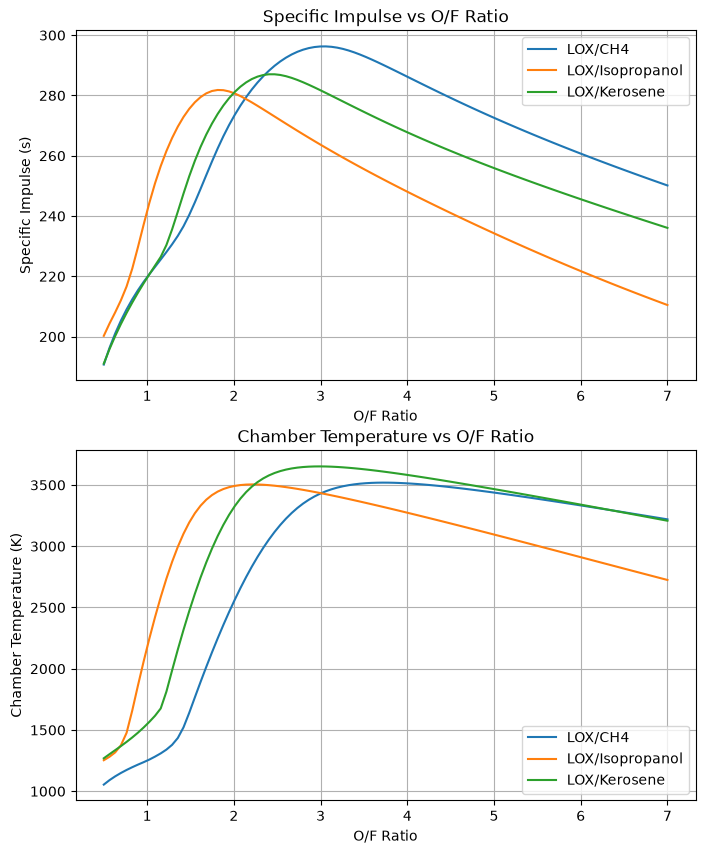

In [ ]:
from rocketcea.cea_obj_w_units import CEA_Obj
import numpy as np
import matplotlib.pyplot as plt

OFs = np.linspace(0.5, 7, 100)  # Oxidizer-to-fuel ratios

propellent_combinations = [
    # ("GOX", "CH4"),
    ("LOX", "CH4"),
    # ("N2O", "Isopropanol"),
    ("LOX", "Isopropanol"),
    ("LOX", "Kerosene"),
    # ("LOX", "RP1"),
]

fig, axs = plt.subplots(2, 1, figsize=(8, 10))
isp_plot = axs[0]
isp_plot.set_title("Specific Impulse vs O/F Ratio")
isp_plot.set_xlabel("O/F Ratio")
isp_plot.set_ylabel("Specific Impulse (s)")
isp_plot.grid()
tc_plot = axs[1]
tc_plot.set_title("Chamber Temperature vs O/F Ratio")
tc_plot.set_xlabel("O/F Ratio")
tc_plot.set_ylabel("Chamber Temperature (K)")
tc_plot.grid()


for ox, fuel in propellent_combinations:
    cea = CEA_Obj(
        oxName = ox,
        fuelName = fuel,
        isp_units='sec',
        cstar_units = 'm/s',
        pressure_units='Bar',
        temperature_units='K',
        sonic_velocity_units='m/s',
        enthalpy_units='J/g',
        density_units='kg/m^3',
        specific_heat_units='J/kg-K',
        viscosity_units='centipoise', # stored value in pa-s
        thermal_cond_units='W/cm-degC', # stored value in W/m-K
        # fac_CR=self.cr,
        make_debug_prints=False)

    isp_values = np.zeros_like(OFs)
    chamber_temps = np.zeros_like(OFs)
    for i, OF in enumerate(OFs):
        # isp_values[i] = cea.get_Isp(Pc=15, MR=OF, eps=5)
        isp_values[i] = cea.estimate_Ambient_Isp(Pc=50,MR=OF,eps=5,Pamb=1.01325)[0]
        chamber_temps[i] = cea.get_Tcomb(Pc=50, MR=OF)

    
    isp_plot.plot(OFs, isp_values, label=f"{ox}/{fuel}")
    isp_plot.legend()

    tc_plot.plot(OFs, chamber_temps, label=f"{ox}/{fuel}")
    tc_plot.legend()

USER_HOME_DIR=C:\Users\Martin


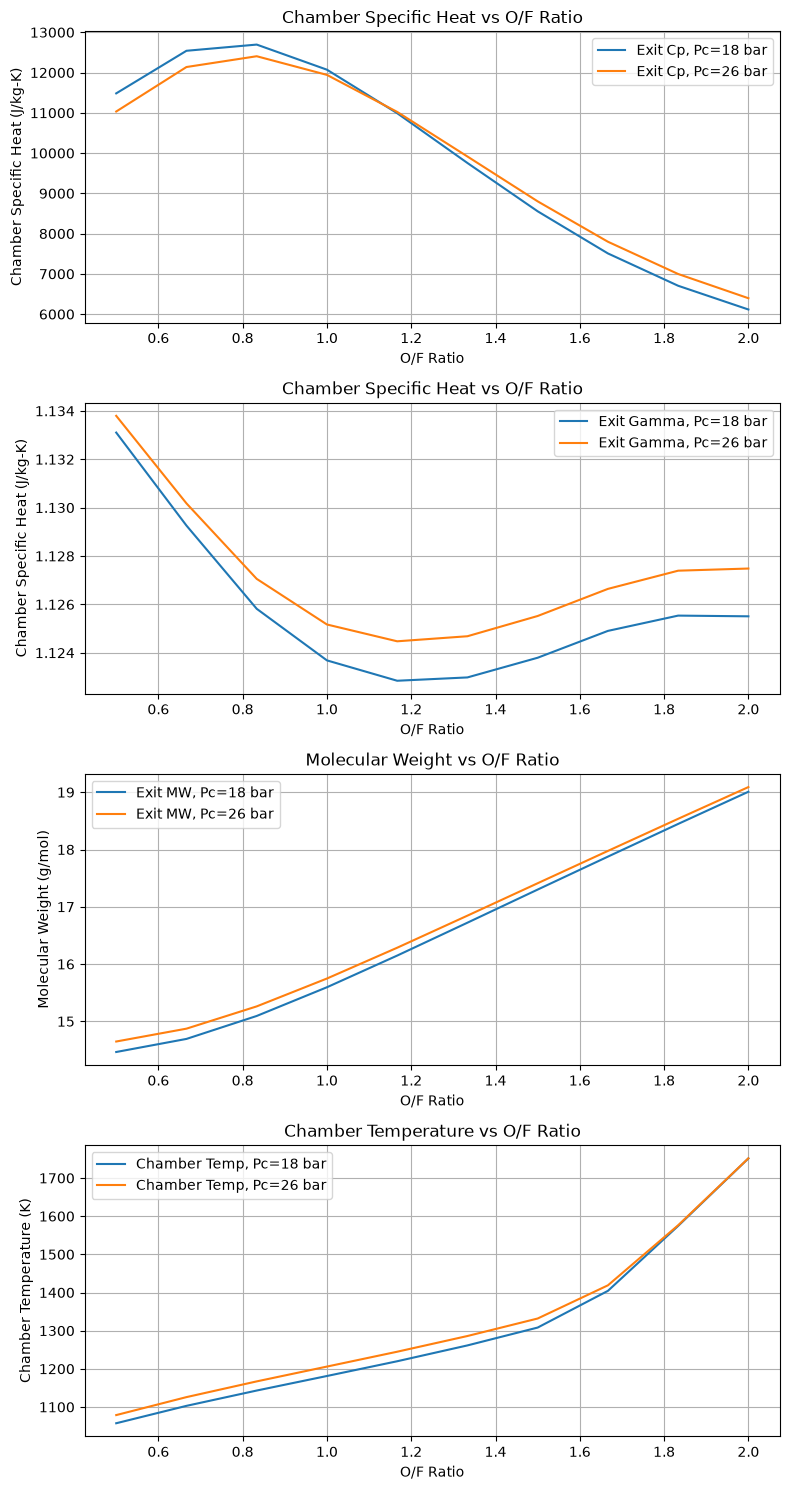

In [1]:
from rocketcea.cea_obj_w_units import CEA_Obj
import numpy as np
import matplotlib.pyplot as plt

OFs = np.linspace(0.5, 2, 10)  # Oxidizer-to-fuel ratios

fig, axs = plt.subplots(4, 1, figsize=(8, 15))
cp_plot = axs[0]
cp_plot.set_title("Chamber Specific Heat vs O/F Ratio")
cp_plot.set_xlabel("O/F Ratio")
cp_plot.set_ylabel("Chamber Specific Heat (J/kg-K)")
cp_plot.grid()
gamma_plot = axs[1]
gamma_plot.set_title("Chamber Specific Heat vs O/F Ratio")
gamma_plot.set_xlabel("O/F Ratio")
gamma_plot.set_ylabel("Chamber Specific Heat (J/kg-K)")
gamma_plot.grid()
mw_plot = axs[2]
mw_plot.set_title("Molecular Weight vs O/F Ratio")
mw_plot.set_xlabel("O/F Ratio")
mw_plot.set_ylabel("Molecular Weight (g/mol)")
mw_plot.grid()
temp_plot = axs[3]
temp_plot.set_title("Chamber Temperature vs O/F Ratio")
temp_plot.set_xlabel("O/F Ratio")
temp_plot.set_ylabel("Chamber Temperature (K)")
temp_plot.grid()
for pc in [18, 26]:
    cea = CEA_Obj(
        oxName = "N2O",
        fuelName = "Isopropanol",
        isp_units='sec',
        cstar_units = 'm/s',
        pressure_units='Bar',
        temperature_units='K',
        sonic_velocity_units='m/s',
        enthalpy_units='J/g',
        density_units='kg/m^3',
        specific_heat_units='J/kg-K',
        viscosity_units='centipoise', # stored value in pa-s
        thermal_cond_units='W/cm-degC', # stored value in W/m-K
        # fac_CR=self.cr,
        make_debug_prints=False)


    chamber_cp = np.zeros_like(OFs)
    exit_cp = np.zeros_like(OFs)
    chamber_gamma = np.zeros_like(OFs)
    exit_gamma = np.zeros_like(OFs)
    chamber_mw = np.zeros_like(OFs)
    exit_mw = np.zeros_like(OFs)
    chamber_temp = np.zeros_like(OFs)
    for i, OF in enumerate(OFs):
        chamber_cp[i] = cea.get_Chamber_Cp(Pc=pc, MR=OF)
        exit_cp[i], _, _, _ = cea.get_Exit_Transport(Pc=pc, MR=OF, eps=6.13)

        chamber_mw[i], chamber_gamma[i] = cea.get_Chamber_MolWt_gamma(Pc=pc, MR=OF)
        exit_mw[i], exit_gamma[i] = cea.get_exit_MolWt_gamma(Pc=pc, MR=OF, eps=6.13)

        chamber_temp[i] = cea.get_Tcomb(Pc=pc, MR=OF)

    # cp_plot.plot(OFs, chamber_cp, label=f"Chamber Cp, Pc={pc} bar")
    cp_plot.plot(OFs, exit_cp, label=f"Exit Cp, Pc={pc} bar")
    cp_plot.legend()

    # gamma_plot.plot(OFs, chamber_gamma, label=f"Chamber Gamma, Pc={pc} bar")
    gamma_plot.plot(OFs, exit_gamma, label=f"Exit Gamma, Pc={pc} bar")
    gamma_plot.legend()

    # mw_plot.plot(OFs, chamber_mw, label=f"Chamber MW, Pc={pc} bar")
    mw_plot.plot(OFs, exit_mw,  label=f"Exit MW, Pc={pc} bar")
    mw_plot.legend()

    temp_plot.plot(OFs, chamber_temp, label=f"Chamber Temp, Pc={pc} bar")
    temp_plot.legend()

fig.tight_layout()